In [1]:
#  05_STACKED_GENERALIZATION.ipynb
#  Bhopal AQI Prediction — Stacked Generalization Model

In [2]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style("whitegrid")
print("✅ All imports successful")
print("=" * 60)
print("  STACKED GENERALIZATION MODEL")
print("  Base learners → OOF predictions → Meta-learner (Ridge)")
print("=" * 60)

✅ All imports successful
  STACKED GENERALIZATION MODEL
  Base learners → OOF predictions → Meta-learner (Ridge)


In [3]:
#  LOAD DATA
train_path = r"D:\bhopal-pollutant-prediction\processed_data\train_engineered.csv"
test_path  = r"D:\bhopal-pollutant-prediction\processed_data\test_engineered.csv"

train = pd.read_csv(train_path, parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(test_path,  parse_dates=['datetime'], index_col='datetime')

print(f"✅ Train: {train.shape}  |  {train.index.min()} → {train.index.max()}")
print(f"✅ Test:  {test.shape}   |  {test.index.min()}  → {test.index.max()}")

✅ Train: (13632, 184)  |  2024-01-01 00:00:00 → 2025-07-21 23:00:00
✅ Test:  (3408, 184)   |  2025-07-22 00:00:00  → 2025-12-10 23:00:00


In [4]:
#  FEATURE PREPARATION
TIME_LEAKERS = ['year', 'month', 'day', 'day_of_month', 'week_of_year']

SAFE_TIME = ['hour_sin','hour_cos','month_sin','month_cos',
             'hour_of_day','day_of_week','is_weekend',
             'is_night','is_morning_rush','is_evening_rush','season']

WEATHER = ['temp','humidity','windspeed','winddir','precip',
           'cloudcover','visibility','sealevelpressure','uvindex']

lag_feats     = [c for c in train.columns if '_lag_' in c]
rolling_feats = [c for c in train.columns if '_roll_' in c]

all_features = list(set(SAFE_TIME + WEATHER + lag_feats + rolling_feats))
all_features = [f for f in all_features if f in train.columns]
all_features = [f for f in all_features if f not in TIME_LEAKERS]

TARGETS = ['PM25_Idgah_Hills', 'PM10_Idgah_Hills', 'NO2_Idgah_Hills']

# Convert to numpy for safe indexing inside manual OOF loop
X_train_np = train[all_features].values
X_test_np  = test[all_features].values
y_train_df = train[TARGETS]
y_test_df  = test[TARGETS]

# Keep DataFrame versions too (needed for final fit)
X_train_df = train[all_features]
X_test_df  = test[all_features]

print(f"\n✅ Features : {len(all_features)}")
print(f"✅ Targets  : {TARGETS}")
print(f"✅ X_train  : {X_train_np.shape}")
print(f"✅ X_test   : {X_test_np.shape}")


✅ Features : 146
✅ Targets  : ['PM25_Idgah_Hills', 'PM10_Idgah_Hills', 'NO2_Idgah_Hills']
✅ X_train  : (13632, 146)
✅ X_test   : (3408, 146)


In [5]:
# BASE LEARNER FACTORY
"""
WHY A FACTORY FUNCTION?
───────────────────────
PptxGenJS and scikit-learn both mutate objects in-place.
We need a FRESH model instance for every fold — never reuse.
The factory returns brand-new objects each call.

WHY n_jobs=1 inside OOF loop?
──────────────────────────────
cross_val_predict(n_jobs=-1) spawns worker processes.
Each worker tries to use XGBoost with n_jobs=-1 too.
This creates a process explosion → ValueError / hang.

Fix: set n_jobs=1 on the models used inside OOF loops.
     After OOF, retrain on full data with n_jobs=-1 (fast).
"""

def make_xgb(n_jobs=1):
    return xgb.XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8,    colsample_bytree=0.8,
        reg_alpha=0.5,    reg_lambda=1.0,
        random_state=42,
        n_jobs=n_jobs,    # 1 during OOF, -1 for final fit
        verbosity=0,
        tree_method='hist'   # faster on tabular data
    )

def make_lgb(n_jobs=1):
    return lgb.LGBMRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        num_leaves=31,    subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5,    reg_lambda=1.0,
        random_state=42,
        n_jobs=n_jobs,
        verbose=-1
    )

def make_rf(n_jobs=1):
    return RandomForestRegressor(
        n_estimators=100, max_depth=10,
        min_samples_split=10, min_samples_leaf=5,
        random_state=42,
        n_jobs=n_jobs
    )

LEARNER_FACTORIES = {
    'XGBoost'      : make_xgb,
    'LightGBM'     : make_lgb,
    'RandomForest' : make_rf,
}

print("✅ Base learner factories defined")
for name in LEARNER_FACTORIES:
    print(f"   • {name}")

✅ Base learner factories defined
   • XGBoost
   • LightGBM
   • RandomForest


In [6]:
#  MANUAL OOF LOOP 
"""
MANUAL OOF GENERATION — HOW IT WORKS:
──────────────────────────────────────
TimeSeriesSplit(n_splits=5) with 13,632 training rows:

  Fold 1: train[    0:2272]  → predict[2272:4544]
  Fold 2: train[    0:4544]  → predict[4544:6816]
  Fold 3: train[    0:6816]  → predict[6816:9088]
  Fold 4: train[    0:9088]  → predict[9088:11360]
  Fold 5: train[    0:11360] → predict[11360:13632]

After all 5 folds, every training row has an OOF prediction.
No test data ever touches the model during OOF generation.
This is the correct time-series-safe way to build meta-features.

We run n_jobs=1 on models INSIDE this loop to avoid
the parallelism conflict that caused the ValueError.
"""

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

oof_preds  = {t: {} for t in TARGETS}
test_preds = {t: {} for t in TARGETS}
base_models= {t: {} for t in TARGETS}

print(f"GENERATING OOF PREDICTIONS (manual fold loop)")
print(f"   Folds     : {N_SPLITS}")
print(f"   Train rows: {len(X_train_np)}")
print(f"   n_jobs=1 during OOF  →  avoids parallelism conflict")
print()

for target in TARGETS:
    y_tr_full = y_train_df[target].values
    print(f"  ── Target: {target} ──")

    for name, factory in LEARNER_FACTORIES.items():
        # Pre-allocate OOF array (NaN for rows not yet predicted)
        oof_arr = np.full(len(X_train_np), np.nan)

        for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(X_train_np)):
            X_fold_tr  = X_train_np[tr_idx]
            y_fold_tr  = y_tr_full[tr_idx]
            X_fold_val = X_train_np[val_idx]

            # Fresh model every fold, n_jobs=1 (no parallel conflict)
            m = factory(n_jobs=1)
            m.fit(X_fold_tr, y_fold_tr)
            oof_arr[val_idx] = m.predict(X_fold_val)

        # How many rows got OOF predictions?
        n_filled = (~np.isnan(oof_arr)).sum()
        oof_r2   = r2_score(y_tr_full[~np.isnan(oof_arr)],
                            oof_arr[~np.isnan(oof_arr)])

        # Store OOF (only filled rows)
        oof_preds[target][name] = oof_arr

        # Retrain on FULL training set with n_jobs=-1 (fast)
        final_model = factory(n_jobs=-1)
        final_model.fit(X_train_df, y_tr_full)
        test_preds[target][name]  = final_model.predict(X_test_df)
        base_models[target][name] = final_model

        print(f"    [{name:<13}]  OOF rows={n_filled}/{len(X_train_np)}  "
              f"OOF R²={oof_r2:.4f}  ✅")

    print()

print("✅ All OOF predictions generated successfully")

GENERATING OOF PREDICTIONS (manual fold loop)
   Folds     : 5
   Train rows: 13632
   n_jobs=1 during OOF  →  avoids parallelism conflict

  ── Target: PM25_Idgah_Hills ──
    [XGBoost      ]  OOF rows=11360/13632  OOF R²=0.9927  ✅
    [LightGBM     ]  OOF rows=11360/13632  OOF R²=0.9936  ✅
    [RandomForest ]  OOF rows=11360/13632  OOF R²=0.9884  ✅

  ── Target: PM10_Idgah_Hills ──
    [XGBoost      ]  OOF rows=11360/13632  OOF R²=0.9905  ✅
    [LightGBM     ]  OOF rows=11360/13632  OOF R²=0.9918  ✅
    [RandomForest ]  OOF rows=11360/13632  OOF R²=0.9882  ✅

  ── Target: NO2_Idgah_Hills ──
    [XGBoost      ]  OOF rows=11360/13632  OOF R²=0.9845  ✅
    [LightGBM     ]  OOF rows=11360/13632  OOF R²=0.9870  ✅
    [RandomForest ]  OOF rows=11360/13632  OOF R²=0.9785  ✅

✅ All OOF predictions generated successfully


In [7]:
# BUILD META-FEATURES & TRAIN META-LEARNER
"""
META-LEARNER STRATEGY:
─────────────────────
The first fold has NO OOF predictions (TimeSeriesSplit skips
the very first chunk as validation target in some configs).
We drop NaN rows before fitting Ridge so the meta-learner
only sees fully predicted training rows.

Ridge(alpha=1.0) learns:
  final_pred = w_xgb*xgb_oof + w_lgb*lgb_oof + w_rf*rf_oof + b

If LightGBM is best for PM2.5, Ridge learns w_lgb > w_xgb > w_rf.
This beats naive 1/3 + 1/3 + 1/3 averaging.
"""

meta_models   = {}
stack_results = []

print("TRAINING RIDGE META-LEARNER")
print()

for target in TARGETS:
    y_tr_full = y_train_df[target].values
    y_te      = y_test_df[target].values

    # Stack OOF arrays → shape (n_train, 3)
    raw_meta_tr = np.column_stack([
        oof_preds[target]['XGBoost'],
        oof_preds[target]['LightGBM'],
        oof_preds[target]['RandomForest'],
    ])

    # Drop rows where ANY model has NaN OOF prediction
    valid_mask     = ~np.isnan(raw_meta_tr).any(axis=1)
    X_meta_train   = raw_meta_tr[valid_mask]
    y_meta_train   = y_tr_full[valid_mask]
    dropped        = (~valid_mask).sum()

    # Test meta-features: stack full-train predictions
    X_meta_test = np.column_stack([
        test_preds[target]['XGBoost'],
        test_preds[target]['LightGBM'],
        test_preds[target]['RandomForest'],
    ])

    # Train Ridge meta-learner
    meta = Ridge(alpha=1.0)
    meta.fit(X_meta_train, y_meta_train)
    meta_models[target] = meta

    # Predictions
    y_pred_meta_tr = meta.predict(X_meta_train)
    y_pred_stack   = meta.predict(X_meta_test)

    # Metrics
    r2_meta_tr = r2_score(y_meta_train, y_pred_meta_tr)
    r2_stack   = r2_score(y_te, y_pred_stack)
    mae_stack  = mean_absolute_error(y_te, y_pred_stack)
    rmse_stack = np.sqrt(mean_squared_error(y_te, y_pred_stack))

    # Individual model test R²
    xgb_r2 = r2_score(y_te, test_preds[target]['XGBoost'])
    lgb_r2 = r2_score(y_te, test_preds[target]['LightGBM'])
    rf_r2  = r2_score(y_te, test_preds[target]['RandomForest'])
    avg_r2 = r2_score(y_te, (test_preds[target]['XGBoost'] +
                              test_preds[target]['LightGBM']) / 2)

    stack_results.append({
        'Target'          : target,
        'XGB_R2'          : xgb_r2,
        'LGB_R2'          : lgb_r2,
        'RF_R2'           : rf_r2,
        'Avg_Ensemble_R2' : avg_r2,
        'Stack_Train_R2'  : r2_meta_tr,
        'Stack_Test_R2'   : r2_stack,
        'Stack_MAE'       : mae_stack,
        'Stack_RMSE'      : rmse_stack,
        'W_XGB'           : meta.coef_[0],
        'W_LGB'           : meta.coef_[1],
        'W_RF'            : meta.coef_[2],
        'OOF_rows_used'   : int(valid_mask.sum()),
        'OOF_rows_dropped': int(dropped),
        'Predictions'     : y_pred_stack,
    })

    print(f"  {target}")
    print(f"    OOF rows used : {valid_mask.sum()} / {len(X_train_np)}  "
          f"(dropped {dropped} NaN rows from fold 0)")
    print(f"    Base R²  →  XGB: {xgb_r2:.4f}  LGB: {lgb_r2:.4f}  RF: {rf_r2:.4f}")
    print(f"    Avg Ensemble R² : {avg_r2:.4f}")
    print(f"    Stacked Test R² : {r2_stack:.4f}   "
          f"← gain: {r2_stack - avg_r2:+.4f}")
    print(f"    MAE : {mae_stack:.2f} µg/m³   RMSE : {rmse_stack:.2f}")
    print(f"    Ridge weights → XGB:{meta.coef_[0]:.3f}  "
          f"LGB:{meta.coef_[1]:.3f}  RF:{meta.coef_[2]:.3f}")
    print()

print("✅ Meta-learner training complete")

TRAINING RIDGE META-LEARNER

  PM25_Idgah_Hills
    OOF rows used : 11360 / 13632  (dropped 2272 NaN rows from fold 0)
    Base R²  →  XGB: 0.9909  LGB: 0.9913  RF: 0.9877
    Avg Ensemble R² : 0.9915
    Stacked Test R² : 0.9914   ← gain: -0.0000
    MAE : 0.57 µg/m³   RMSE : 1.14
    Ridge weights → XGB:0.413  LGB:0.729  RF:-0.135

  PM10_Idgah_Hills
    OOF rows used : 11360 / 13632  (dropped 2272 NaN rows from fold 0)
    Base R²  →  XGB: 0.9961  LGB: 0.9962  RF: 0.9937
    Avg Ensemble R² : 0.9964
    Stacked Test R² : 0.9958   ← gain: -0.0006
    MAE : 1.85 µg/m³   RMSE : 2.76
    Ridge weights → XGB:0.175  LGB:0.815  RF:0.020

  NO2_Idgah_Hills
    OOF rows used : 11360 / 13632  (dropped 2272 NaN rows from fold 0)
    Base R²  →  XGB: 0.9892  LGB: 0.9902  RF: 0.9857
    Avg Ensemble R² : 0.9901
    Stacked Test R² : 0.9906   ← gain: +0.0004
    MAE : 0.30 µg/m³   RMSE : 0.62
    Ridge weights → XGB:0.248  LGB:0.969  RF:-0.201

✅ Meta-learner training complete


In [8]:
#  RESULTS TABLE
results_df = pd.DataFrame(stack_results)
print("\nFULL RESULTS COMPARISON")
print("=" * 85)
cols = ['Target','XGB_R2','LGB_R2','RF_R2',
        'Avg_Ensemble_R2','Stack_Test_R2','Stack_MAE','Stack_RMSE']
print(results_df[cols].round(4).to_string(index=False))

results_df['Gain_vs_Avg'] = (results_df['Stack_Test_R2']
                              - results_df['Avg_Ensemble_R2'])
print(f"\n  Average R² gain over simple ensemble : "
      f"{results_df['Gain_vs_Avg'].mean():+.4f}")
print(f"  Average Stacked Test R²              : "
      f"{results_df['Stack_Test_R2'].mean():.4f}")


FULL RESULTS COMPARISON
          Target  XGB_R2  LGB_R2  RF_R2  Avg_Ensemble_R2  Stack_Test_R2  Stack_MAE  Stack_RMSE
PM25_Idgah_Hills  0.9909  0.9913 0.9877           0.9915         0.9914     0.5699      1.1428
PM10_Idgah_Hills  0.9961  0.9962 0.9937           0.9964         0.9958     1.8491      2.7641
 NO2_Idgah_Hills  0.9892  0.9902 0.9857           0.9901         0.9906     0.2967      0.6248

  Average R² gain over simple ensemble : -0.0001
  Average Stacked Test R²              : 0.9926


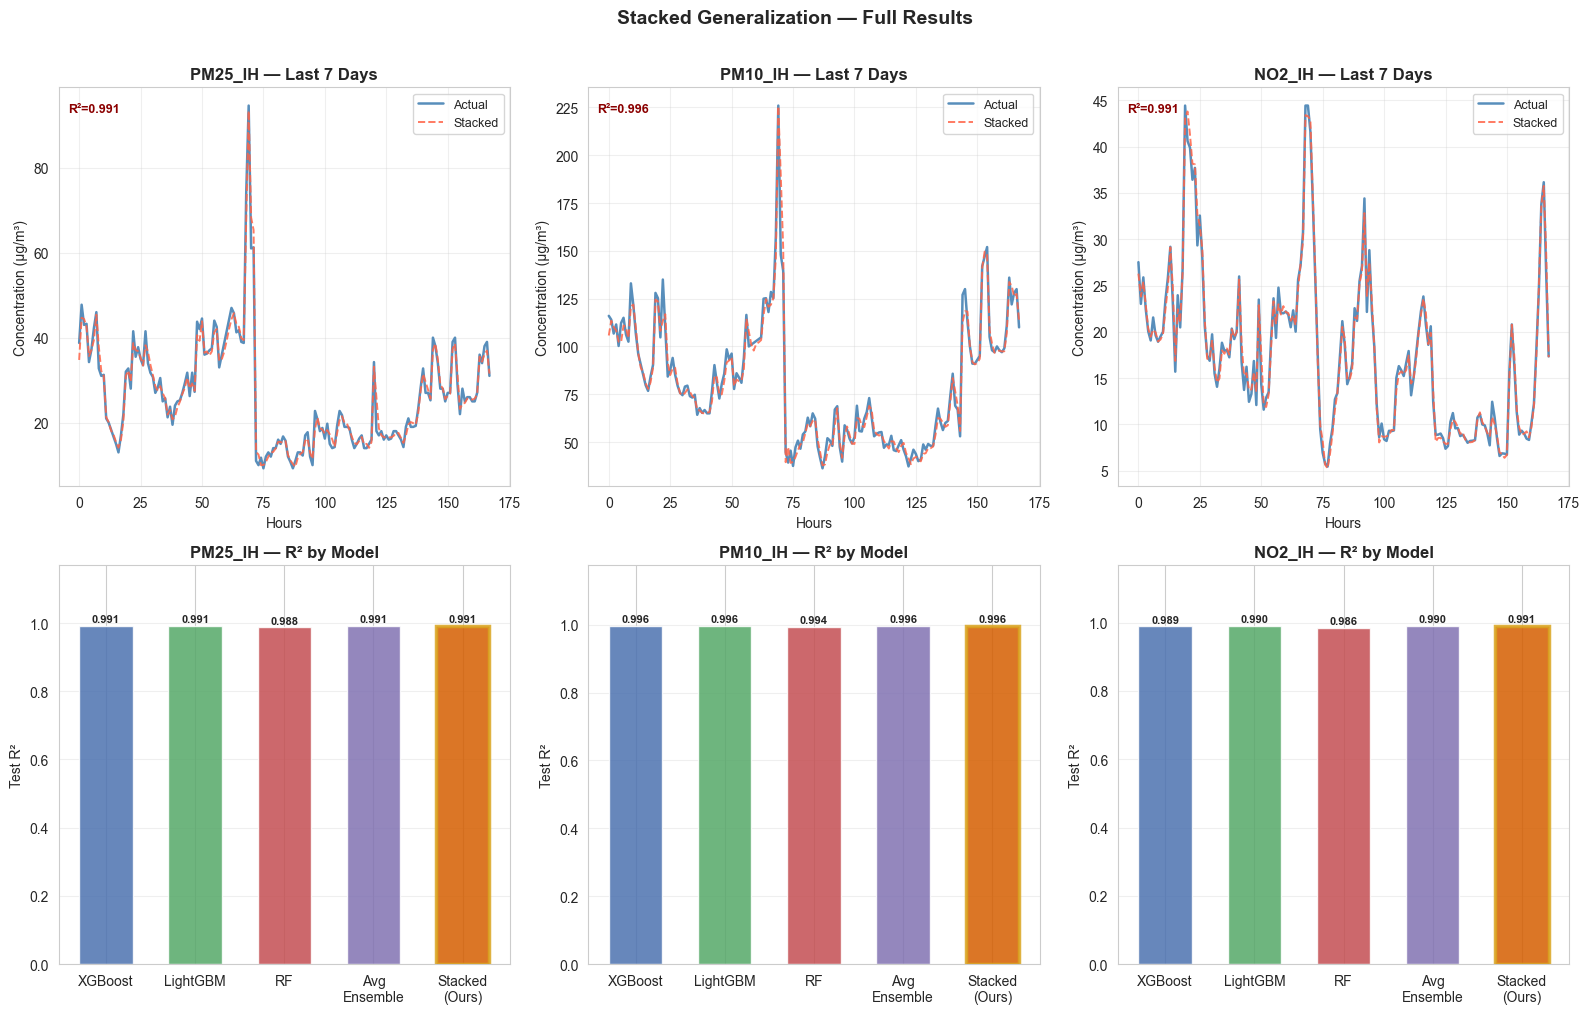

✅ Saved: stacked_results.png


In [9]:
#  VISUALIZATION
fig, axes = plt.subplots(2, len(TARGETS), figsize=(16, 10))

for idx, result in enumerate(stack_results):
    target = result['Target']
    y_te   = y_test_df[target].values
    y_pred = result['Predictions']
    short  = (target.replace('_Idgah_Hills','_IH')
                    .replace('_TT_Nagar','_TT')
                    .replace('_Paryavaran_Parisar','_PP'))

    # ── Row 0 : time series (last week) ──────────────────────
    ax = axes[0, idx]
    n  = min(168, len(y_te))
    ax.plot(y_te[-n:],   color='steelblue', lw=1.8,
            label='Actual', alpha=0.9)
    ax.plot(y_pred[-n:], color='tomato',    lw=1.4,
            label='Stacked', alpha=0.85, linestyle='--')
    ax.set_title(f'{short} — Last 7 Days', fontweight='bold')
    ax.set_xlabel('Hours')
    ax.set_ylabel('Concentration (µg/m³)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.96, f"R²={result['Stack_Test_R2']:.3f}",
            transform=ax.transAxes, fontsize=9,
            va='top', color='darkred', fontweight='bold')

    # ── Row 1 : model R² comparison bar ──────────────────────
    ax2 = axes[1, idx]
    labels = ['XGBoost','LightGBM','RF','Avg\nEnsemble','Stacked\n(Ours)']
    r2s    = [result['XGB_R2'],   result['LGB_R2'],
              result['RF_R2'],    result['Avg_Ensemble_R2'],
              result['Stack_Test_R2']]
    colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#D55E00']
    bars   = ax2.bar(labels, r2s, color=colors,
                     alpha=0.85, edgecolor='white', width=0.6)

    # Gold border on the stacked bar
    bars[-1].set_edgecolor('goldenrod')
    bars[-1].set_linewidth(2.5)

    ax2.set_title(f'{short} — R² by Model', fontweight='bold')
    ax2.set_ylabel('Test R²')
    pos_r2s = [max(v, 0) for v in r2s]
    ax2.set_ylim(0, max(pos_r2s) * 1.18 if max(pos_r2s) > 0 else 0.1)
    ax2.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, r2s):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 max(v, 0) + 0.005,
                 f'{v:.3f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Stacked Generalization — Full Results',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stacked_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: stacked_results.png")

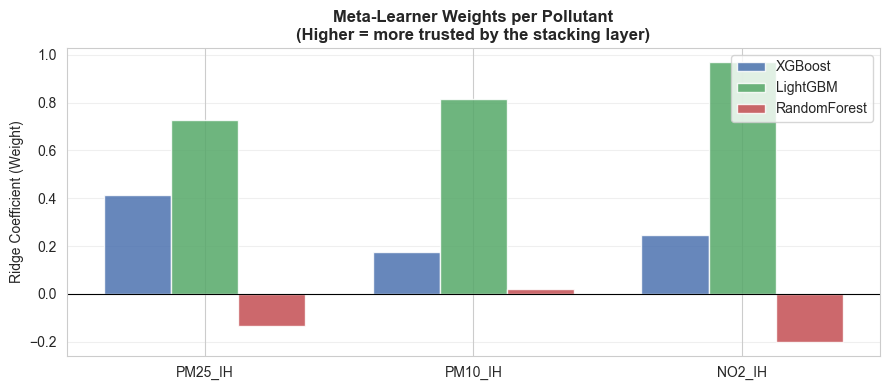

✅ Saved: meta_weights.png


In [10]:
#  META-WEIGHTS CHART
fig, ax = plt.subplots(figsize=(9, 4))
learner_names = ['XGBoost', 'LightGBM', 'RandomForest']
weight_keys   = ['W_XGB', 'W_LGB', 'W_RF']
x     = np.arange(len(TARGETS))
width = 0.25
colors = ['#4C72B0','#55A868','#C44E52']

for i, (name, key) in enumerate(zip(learner_names, weight_keys)):
    weights = [results_df[results_df['Target']==t][key].values[0]
               for t in TARGETS]
    ax.bar(x + i*width, weights, width, label=name,
           color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(
    [t.replace('_Idgah_Hills','_IH').replace('_TT_Nagar','_TT') for t in TARGETS],
    fontsize=10
)
ax.set_ylabel('Ridge Coefficient (Weight)')
ax.set_title('Meta-Learner Weights per Pollutant\n'
             '(Higher = more trusted by the stacking layer)',
             fontweight='bold')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('meta_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: meta_weights.png")

In [11]:
#  SAVE MODELS
save_dir = Path(r"D:\bhopal-pollutant-prediction\models_stacked")
save_dir.mkdir(parents=True, exist_ok=True)

for target in TARGETS:
    safe = target.replace('.', '_')
    for name in LEARNER_FACTORIES:
        joblib.dump(base_models[target][name],
                    save_dir / f"base_{name}_{safe}.joblib")
    joblib.dump(meta_models[target],
                save_dir / f"meta_ridge_{safe}.joblib")
    print(f"✅ Saved: {target}")

results_df.drop(columns=['Predictions']).to_csv(
    save_dir / "stacked_results.csv", index=False)
print(f"\n✅ All models saved → {save_dir}")
print("✅ STACKED GENERALIZATION COMPLETE!")

✅ Saved: PM25_Idgah_Hills
✅ Saved: PM10_Idgah_Hills
✅ Saved: NO2_Idgah_Hills

✅ All models saved → D:\bhopal-pollutant-prediction\models_stacked
✅ STACKED GENERALIZATION COMPLETE!


In [12]:
#  HOW TO LOAD & USE LATER
print("""
══════════════════════════════════════════════════════
  LOADING AND USING THE STACKED MODEL:
══════════════════════════════════════════════════════

import joblib, numpy as np

target   = 'PM25_Idgah_Hills'
safe     = target.replace('.', '_')
base_dir = r"D:/bhopal-pollutant-prediction/models_stacked"

# Load
xgb_m  = joblib.load(f"{base_dir}/base_XGBoost_{safe}.joblib")
lgb_m  = joblib.load(f"{base_dir}/base_LightGBM_{safe}.joblib")
rf_m   = joblib.load(f"{base_dir}/base_RandomForest_{safe}.joblib")
meta_m = joblib.load(f"{base_dir}/meta_ridge_{safe}.joblib")

# Predict on new feature-engineered data (new_X = DataFrame)
p1 = xgb_m.predict(new_X)
p2 = lgb_m.predict(new_X)
p3 = rf_m.predict(new_X)

X_meta        = np.column_stack([p1, p2, p3])
final_pred    = meta_m.predict(X_meta)
print(f"PM2.5 prediction: {final_pred[:5]}")
""")


══════════════════════════════════════════════════════
  LOADING AND USING THE STACKED MODEL:
══════════════════════════════════════════════════════

import joblib, numpy as np

target   = 'PM25_Idgah_Hills'
safe     = target.replace('.', '_')
base_dir = r"D:/bhopal-pollutant-prediction/models_stacked"

# Load
xgb_m  = joblib.load(f"{base_dir}/base_XGBoost_{safe}.joblib")
lgb_m  = joblib.load(f"{base_dir}/base_LightGBM_{safe}.joblib")
rf_m   = joblib.load(f"{base_dir}/base_RandomForest_{safe}.joblib")
meta_m = joblib.load(f"{base_dir}/meta_ridge_{safe}.joblib")

# Predict on new feature-engineered data (new_X = DataFrame)
p1 = xgb_m.predict(new_X)
p2 = lgb_m.predict(new_X)
p3 = rf_m.predict(new_X)

X_meta        = np.column_stack([p1, p2, p3])
final_pred    = meta_m.predict(X_meta)
print(f"PM2.5 prediction: {final_pred[:5]}")

